# M1.Ex2: Model Experience vs Salary

- Run: [**Open In Colab**](https://colab.research.google.com/github/HassanAlgoz/B5/blob/main/content/W3/M1/exercises/ex2_reg.ipynb)
- Raw Dataset: [Salary Data.csv](https://raw.githubusercontent.com/HassanAlgoz/B5/main/content/datasets/Salary%20Data.csv)

In [1]:
import pandas as pd
import sklearn

### Step 1. Load the data

In [2]:
url = "https://raw.githubusercontent.com/HassanAlgoz/B5/main/content/datasets/Salary%20Data.csv"
df = pd.read_csv(url)

In [4]:
print(df.columns)

Index(['Experience Years', 'Salary'], dtype='str')


### Step 2.a Assign variables `X` to the features and `y` to the target

In [10]:
X = df[['Experience Years']] 
y = df['Salary']   

### Step 2.b print the type of each

In [7]:
print(f"Type of X: {type(X)}")
print(f"Type of y: {type(y)}")

Type of X: <class 'pandas.DataFrame'>
Type of y: <class 'pandas.Series'>


### Step 2.c identify whether the target is categorical or numerical & whether the task is regression or classification

In [11]:
if df['Salary'].dtype in ['int64', 'float64']:
    target_type = "Numerical"
    task = "Regression"
else:
    target_type = "Categorical"
    task = "Classification"

print(f"Target Type: {target_type}")
print(f"Machine Learning Task: {task}")

Target Type: Numerical
Machine Learning Task: Regression


### Step 3. Identify the number of samples and columns of both the data matrix and the target

In [12]:
print(f"Shape of X: {X.shape}")
print(f"Shape of y: {y.shape}")

Shape of X: (40, 1)
Shape of y: (40,)


### Step 4. Summarize the distribution of the data (min, max, median, mean, and standard deviation)

In [13]:
print(df.describe())

print("\nMedian values:")
print(df.median(numeric_only=True))

       Experience Years         Salary
count         40.000000      40.000000
mean           5.152500   74743.625000
std            2.663715   25947.122885
min            1.100000   37731.000000
25%            3.200000   56878.250000
50%            4.600000   64472.500000
75%            6.875000   95023.250000
max           10.500000  122391.000000

Median values:
Experience Years        4.6
Salary              64472.5
dtype: float64


### Step 5. Plot the feature vs the target

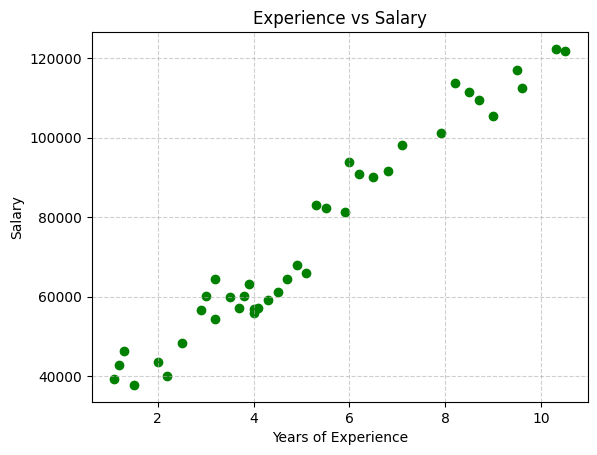

In [14]:
import matplotlib.pyplot as plt

plt.scatter(X, y, color='green')
plt.title('Experience vs Salary')
plt.xlabel('Years of Experience')
plt.ylabel('Salary')
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

### Step 6. What is the relationship between the feature and the target? (increasing or decreasing or none)

In [ ]:
 increasing 

### Step 7. Initialize a regression model

In [15]:
from sklearn.linear_model import LinearRegression

model = LinearRegression()

### Step 8. Split the dataset into train and test sets

In [16]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Training set size: {len(X_train)}")
print(f"Test set size: {len(X_test)}")

Training set size: 32
Test set size: 8


### Step 9.a Train the model on the training set

In [17]:
model.fit(X_train, y_train)
print("Model trained successfully.")

Model trained successfully.


### Step 9.b Identify the learned slope and the y-intercept of the linear regression model

In [18]:
slope = model.coef_[0]
intercept = model.intercept_

print(f"Slope (Yearly increase): {slope:.2f}")
print(f"Y-intercept (Base salary): {intercept:.2f}")

Slope (Yearly increase): 9408.03
Y-intercept (Base salary): 26716.25


### Step 9.c how much salary does a person get with 2 years of experience?

In [19]:
salary_2_years = model.predict([[2]])
print(f"Estimated salary for 2 years of experience: {salary_2_years[0]:.2f}")

Estimated salary for 2 years of experience: 45532.31


c:\Users\mhmmd\Downloads\python-sdaia-aai\.venv\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


### Step 9.d how much does an increase of 6 months of experience adds to a person's salary?

In [20]:
six_months_increase = slope * 0.5
print(f"An increase of 6 months adds: {six_months_increase:.2f} to the salary")

An increase of 6 months adds: 4704.02 to the salary


### Step 9.e if one has zero experience, then how much is the estimated salary?

In [21]:
print(f"Estimated salary with zero experience: {intercept:.2f}")

Estimated salary with zero experience: 26716.25


### Step 10. Evaluate the model on the test set

In [22]:
from sklearn.metrics import r2_score, mean_absolute_error

y_pred = model.predict(X_test)

score = r2_score(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)

print(f"R-squared Score: {score:.4f}")
print(f"Mean Absolute Error: ${mae:.2f}")

R-squared Score: 0.9069
Mean Absolute Error: $6419.91


### Step 11. Take a sample of three rows from the test set and make a prediction on them and check whether they match the true label or not

In [23]:
sample_X = X_test.head(3)
sample_y_true = y_test.head(3)
sample_y_pred = model.predict(sample_X)

comparison = pd.DataFrame({
    'Years Experience': sample_X.values.flatten(),
    'Actual Salary': sample_y_true.values,
    'Predicted Salary': sample_y_pred
})

print(comparison)

   Years Experience  Actual Salary  Predicted Salary
0               4.5          61111      69052.390902
1               4.0          56957      64348.375266
2               4.0          55794      64348.375266


### Step 12. Plot the data and the regression line

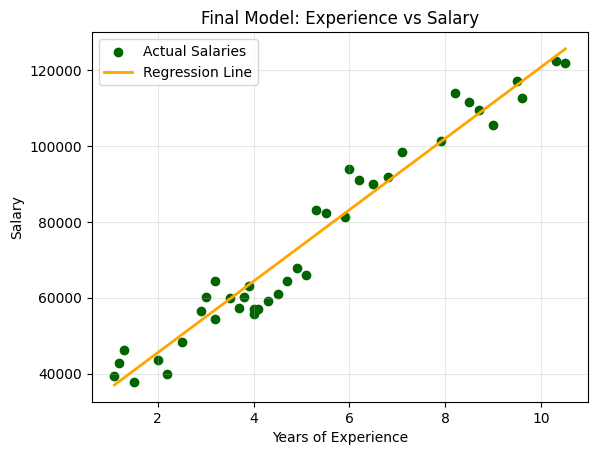

In [24]:
import matplotlib.pyplot as plt

plt.scatter(X, y, color='darkgreen', label='Actual Salaries')

plt.plot(X, model.predict(X), color='orange', linewidth=2, label='Regression Line')

plt.title('Final Model: Experience vs Salary')
plt.xlabel('Years of Experience')
plt.ylabel('Salary')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()